In [2]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob
import xarray as xr
plt.rcParams['text.usetex'] = True

In [3]:
post_path = '/pscratch/sd/m/mckenna/dharma_3d/'

ii=1
bin_cntl_3d_files = sorted(glob.glob(post_path+'cntl_bin_ice/*nc'))[::ii]
bin_cntl_noturb_3d_files = sorted(glob.glob(post_path+'cntl_bin_ice_noturb/*nc'))[::ii]
bin_sip_3d_files  = sorted(glob.glob(post_path+'sip_bin_ice/*nc'))[::ii]
bin_sip10x_3d_files  = sorted(glob.glob(post_path+'sip_10x_bin_ice/*nc'))[::ii]
bin_sip10x_noturb_3d_files  = sorted(glob.glob(post_path+'sip_10x_bin_ice_noturb/*nc'))[::ii]
                                       
num_bin_cntl_3d_files = len(bin_cntl_3d_files)
num_bin_cntl_noturb_3d_files = len(bin_cntl_noturb_3d_files)
num_bin_sip_3d_files = len(bin_sip_3d_files)
num_bin_sip10x_3d_files = len(bin_sip10x_3d_files)
num_bin_sip10x_noturb_3d_files = len(bin_sip10x_noturb_3d_files)

print(num_bin_cntl_3d_files)
print(num_bin_cntl_noturb_3d_files)
print(num_bin_sip_3d_files)
print(num_bin_sip10x_3d_files)
print(num_bin_sip10x_noturb_3d_files)

37
37
37
37
37


In [4]:
# ============================================================
# PDFs of Ni from 3D BIN simulations
# Left : all cloudy points     (qi > 1e-3 g/kg)
# Right: cloudy updraft points (qi > 1e-3 g/kg AND w_interp > 1 m/s)
# ni [#/cm3] -> L-1 (*1e3); qi threshold = 1e-6 kg/kg
# Histogram counts accumulated file-by-file to avoid memory issues
# ============================================================
Fontsize    = 14
nbins       = 30
log10_edges = np.linspace(-4, 3, nbins + 1)   # L-1 space: 0.01 to 10000
qi_thresh   = 1.e-6    # kg/kg  (= 1e-3 g/kg)
w_thresh    = 1.0      # m/s
ni_thresh   = 1.e-4    # L-1 (exclude near-zero ice)

sim_labels    = [r'\textbf{CNTL}', r'\textbf{SIP}', r'\textbf{SIP\_10X}']
sim_colors    = ['k', 'royalblue', 'tomato']
sim_lws       = [2, 2, 2]
sim_file_lists = [bin_cntl_3d_files, bin_sip_3d_files, bin_sip10x_3d_files]

# Accumulate counts for each sim (two masks: all cloudy, cloudy updraft)
counts_cld  = []   # one array per sim
counts_up   = []

for i,file_list in enumerate(sim_file_lists):
    print(sim_labels[i])
    c_cld = np.zeros(nbins)
    c_up  = np.zeros(nbins)
    for fpath in file_list:
        with xr.open_dataset(fpath, decode_times=False) as ds_f:
            ni_raw = ds_f['ni'].values.ravel()          # #/cm3
            qi_raw = ds_f['qi'].values.ravel()          # kg/kg
            w_raw  = ds_f['w_interp'].values.ravel()    # m/s

        ni_L = ni_raw * 1.e3                            # -> L-1
        print(np.max(ni_L))

        mask_cld = (qi_raw > qi_thresh) & (ni_L > ni_thresh)
        mask_up  = mask_cld & (w_raw > w_thresh)

        if mask_cld.any():
            h, _ = np.histogram(np.log10(ni_L[mask_cld]), bins=log10_edges)
            c_cld += h
        if mask_up.any():
            h, _ = np.histogram(np.log10(ni_L[mask_up]),  bins=log10_edges)
            c_up  += h

    counts_cld.append(c_cld)
    counts_up.append(c_up)



\textbf{CNTL}


/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


0.35688864927407354
0.25309109196120977
0.3364117193420562
0.5722358816613107
0.47366676114657735
0.38784990676959685
0.6638346968707228
0.49060016069940354
0.46213742685923137
0.7832427525103414
1.0011050895395612
0.9962440016691443
1.3127859890981168
1.4230605857493122
1.0328848709827934
0.5859907444802988
0.6710295704709062
0.7075971615135918
1.084241337222037
0.7874271786652937
0.811543827239556
0.5431725131715298
0.6123975299415616
0.7789297888823586
0.6553824106350192
0.7683844248408185
1.1424794384559043
0.6014919363082806
0.6359524481503883
0.587909491636284
0.4998000592382026
0.5984235495681027
0.6434102300951586
0.5268128586565755
0.7709136561369478
0.707760164236982
0.6517951617810228
\textbf{SIP}
0.35688864927407354
0.302435118887825
0.37039053884569517
0.6120023567312874
0.522735059385804
0.44271174139358377
0.6548831597178175
0.39183067608541455
0.5151445580871583
0.7415253862228992
0.959210920203664
1.3112536220965652
1.4621823406790666
1.3075743699114186
0.8813699763156

In [5]:
bulk_cntl_3d_files = sorted(glob.glob(post_path+'cntl_bulk_ice_ABIFM/*nc'))#[::5]
num_bulk_cntl_3d_files = len(bulk_cntl_3d_files)
print(num_bulk_cntl_3d_files)
bulk_sip_3d_files = sorted(glob.glob(post_path+'sip_bulk_ice_ABIFM/*nc'))#[::5]
num_bulk_sip_3d_files = len(bulk_sip_3d_files)
print(num_bulk_sip_3d_files)
bulk_sip_10x_3d_files = sorted(glob.glob(post_path+'sip_10x_bulk_ice_ABIFM/*nc'))#[::5]
num_bulk_sip_10x_3d_files = len(bulk_sip_10x_3d_files)
print(num_bulk_sip_10x_3d_files)

37
37
37


In [6]:
# ============================================================
# PDFs of Ni from 3D BULK simulations
# Left : all cloudy points     (qi > 1e-3 g/kg)
# Right: cloudy updraft points (qi > 1e-3 g/kg AND w_interp > 1 m/s)
# ni [#/cm3] -> L-1 (*1e3); qi threshold = 1e-6 kg/kg
# Histogram counts accumulated file-by-file to avoid memory issues
# ============================================================
Fontsize    = 14
nbins       = 30
log10_edges = np.linspace(-4, 3, nbins + 1)   # L-1 space: 0.01 to 10000
qi_thresh   = 1.e-6    # kg/kg  (= 1e-3 g/kg)
w_thresh    = 1.0      # m/s
ni_thresh   = 1.e-4    # L-1 (exclude near-zero ice)

bulk_sim_labels    = [r'\textbf{CNTL}', r'\textbf{SIP}', r'\textbf{SIP\_10X}']
bulk_sim_colors    = ['k', 'royalblue', 'tomato']
bulk_sim_lws       = [2, 2, 2]
bulk_sim_file_lists = [bulk_cntl_3d_files, bulk_sip_3d_files, bulk_sip_10x_3d_files]

# Accumulate counts for each sim (two masks: all cloudy, cloudy updraft)
bulk_counts_cld  = []   # one array per sim
bulk_counts_up   = []


for i,file_list in enumerate(bulk_sim_file_lists):
    print(sim_labels[i])
    c_cld = np.zeros(nbins)
    c_up  = np.zeros(nbins)
    for fpath in file_list:
        with xr.open_dataset(fpath, decode_times=False) as ds_f:
            nic_raw = ds_f['nic'].values          # #/kg
            nif_raw = ds_f['nif'].values          # #/kg
            nid_raw = ds_f['nid'].values          # #/kg
            qic_raw = ds_f['qic'].values          # kg/kg
            qif_raw = ds_f['qif'].values          # kg/kg
            qid_raw = ds_f['qid'].values          # kg/kg
            qi_raw = qic_raw + qid_raw + qif_raw
            ni_raw = nic_raw + nid_raw + nif_raw
            w_raw  = ds_f['w_interp'].values    # m/s
            rhobar_raw = ds_f['rhobar'].values        # kg/m3
            nic_raw = nic_raw*rhobar_raw*1.e-6 # convert to #/cc
            ni_raw = ni_raw*rhobar_raw*1.e-6 # convert to #/cc
            nic_raw = nic_raw.ravel()
            ni_raw = ni_raw.ravel()
            qic_raw = qic_raw.ravel()
            qi_raw = qi_raw.ravel()
            w_raw = w_raw.ravel()

            

        ni_L = ni_raw * 1.e3                            # -> L-1
        nic_L = nic_raw * 1.e3                            # -> L-1
        #print(np.max(ni_L))

        #mask_cld = (qic_raw > qi_thresh) & (nic_L > ni_thresh)
        mask_cld = (qi_raw > qi_thresh) & (ni_L > ni_thresh)
        mask_up  = mask_cld & (w_raw > w_thresh)
        #print(np.unique(mask_up))

        if mask_cld.any():
            h, _ = np.histogram(np.log10(ni_L[mask_cld]), bins=log10_edges)
            c_cld += h
        if mask_up.any():
            h, _ = np.histogram(np.log10(ni_L[mask_up]),  bins=log10_edges)
            c_up  += h

    bulk_counts_cld.append(c_cld)
    bulk_counts_up.append(c_up)


\textbf{CNTL}
\textbf{SIP}
\textbf{SIP\_10X}


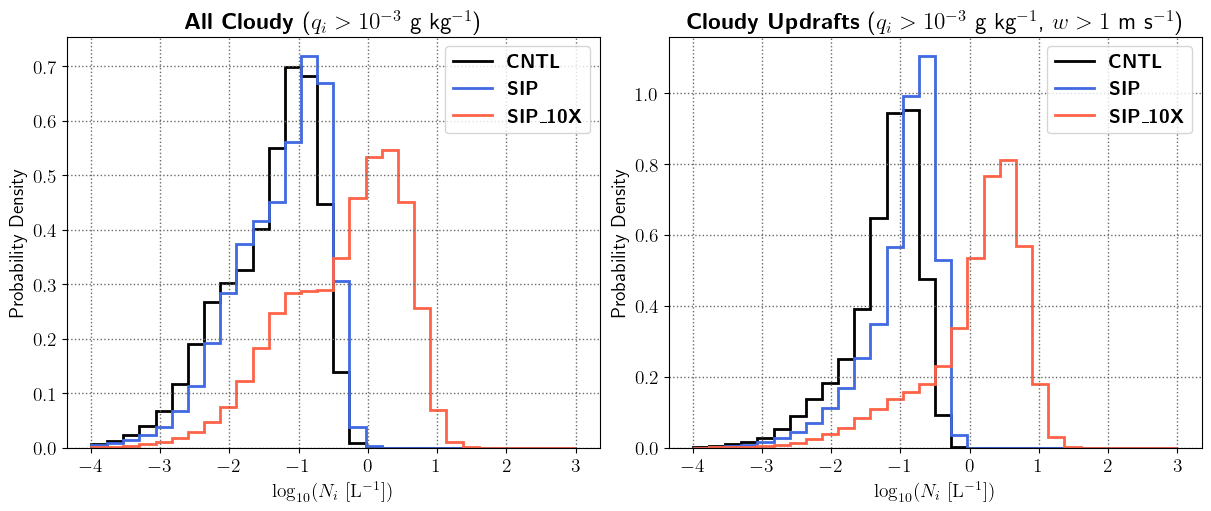

In [7]:
# Normalise to probability density
def to_density(counts, edges):
    total = counts.sum()
    if total == 0:
        return counts.astype(float)
    widths = np.diff(edges)
    return counts / (total * widths)

fig_pdf3d, (ax_cld, ax_up) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for counts, color, lw, name in zip(counts_cld, sim_colors, sim_lws, sim_labels):
    dens = to_density(counts, log10_edges)
    ax_cld.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)
#ax_cld.stairs(to_density(bulk_counts_cld[0],log10_edges),log10_edges,color='teal',lw=lw,linestyle='solid',label=r'\textbf{CNTL BULK}')

for counts, color, lw, name in zip(counts_up, sim_colors, sim_lws, sim_labels):
    dens = to_density(counts, log10_edges)
    ax_up.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)
#ax_up.stairs(to_density(bulk_counts_up[0],log10_edges),log10_edges,color='teal',lw=lw,linestyle='solid',label=r'\textbf{CNTL BULK}')

for ax, title in [(ax_cld, r'\textbf{All Cloudy} ($q_i > 10^{-3}$ g kg$^{-1}$)'),
                  (ax_up,  r'\textbf{Cloudy Updrafts} ($q_i > 10^{-3}$ g kg$^{-1}$, $w > 1$ m s$^{-1}$)')]:
    ax.set_xlabel(r'$\log_{10}(N_i\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)
    ax.set_ylabel('Probability Density', fontsize=Fontsize)
    ax.tick_params(labelsize=Fontsize)
    ax.legend(fontsize=Fontsize)
    ax.grid(ls='dotted', lw=1, c='dimgrey')
    ax.set_title(title, fontsize=Fontsize * 1.2)

plt.show()


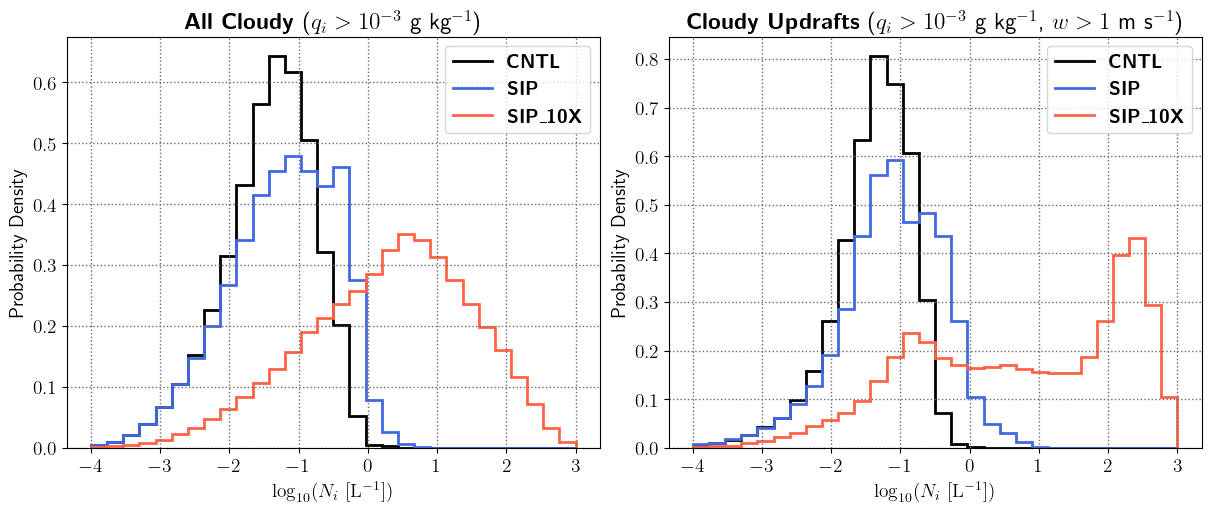

In [8]:
# Normalise to probability density
def to_density(counts, edges):
    total = counts.sum()
    if total == 0:
        return counts.astype(float)
    widths = np.diff(edges)
    return counts / (total * widths)

fig_pdf3d, (ax_cld, ax_up) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for counts, color, lw, name in zip(bulk_counts_cld, bulk_sim_colors, bulk_sim_lws, bulk_sim_labels):
    dens = to_density(counts, log10_edges)
    ax_cld.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)
#ax_cld.stairs(to_density(bulk_counts_cld[0],log10_edges),log10_edges,color='teal',lw=lw,linestyle='solid',label=r'\textbf{CNTL BULK}')

for counts, color, lw, name in zip(bulk_counts_up, bulk_sim_colors, bulk_sim_lws, bulk_sim_labels):
    dens = to_density(counts, log10_edges)
    ax_up.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)
#ax_up.stairs(to_density(bulk_counts_up[0],log10_edges),log10_edges,color='teal',lw=lw,linestyle='solid',label=r'\textbf{CNTL BULK}')

for ax, title in [(ax_cld, r'\textbf{All Cloudy} ($q_i > 10^{-3}$ g kg$^{-1}$)'),
                  (ax_up,  r'\textbf{Cloudy Updrafts} ($q_i > 10^{-3}$ g kg$^{-1}$, $w > 1$ m s$^{-1}$)')]:
    ax.set_xlabel(r'$\log_{10}(N_i\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)
    ax.set_ylabel('Probability Density', fontsize=Fontsize)
    ax.tick_params(labelsize=Fontsize)
    ax.legend(fontsize=Fontsize)
    ax.grid(ls='dotted', lw=1, c='dimgrey')
    ax.set_title(title, fontsize=Fontsize * 1.2)
    #ax.set_yscale('log')
    
plt.show()


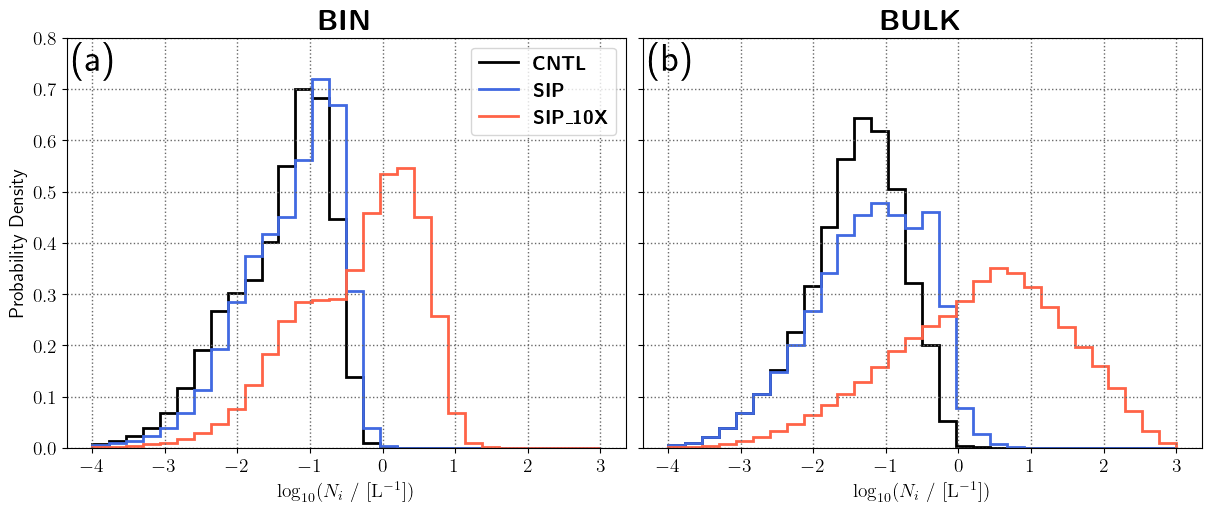

In [9]:
# Normalise to probability density
def to_density(counts, edges):
    total = counts.sum()
    if total == 0:
        return counts.astype(float)
    widths = np.diff(edges)
    return counts / (total * widths)

fig_pdf3d, (ax_bin, ax_bulk) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for counts, color, lw, name in zip(counts_cld, sim_colors, sim_lws, sim_labels):
    dens = to_density(counts, log10_edges)
    ax_bin.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)

for counts, color, lw, name in zip(bulk_counts_cld, bulk_sim_colors, bulk_sim_lws, bulk_sim_labels):
    dens = to_density(counts, log10_edges)
    ax_bulk.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)

for ax, title in [(ax_bin, r'\textbf{BIN}'),
                  (ax_bulk,  r'\textbf{BULK}')]:
    ax.set_xlabel(r'$\log_{10}(N_i\ /\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)
    ax.tick_params(labelsize=Fontsize)
    ax.grid(ls='dotted', lw=1, c='dimgrey')
    ax.set_title(title, fontsize=Fontsize * 1.5)
    #ax.set_yscale('log')

ax_bin.legend(fontsize=Fontsize)

ax_bin.set_ylabel('Probability Density', fontsize=Fontsize)
ax_bin.set_ylim(0,0.8)
ax_bulk.set_ylim(0,0.8)
ax_bin.set_yticks(np.arange(0,0.9,0.1))
ax_bulk.set_yticks(np.arange(0,0.9,0.1))
ax_bulk.set_yticklabels([])

ax_bin.text(0.01,0.99,'(a)',fontsize=Fontsize*2.,transform=ax_bin.transAxes,va='top',ha='left')
ax_bulk.text(0.01,0.99,'(b)',fontsize=Fontsize*2.,transform=ax_bulk.transAxes,va='top',ha='left')

plt.show()


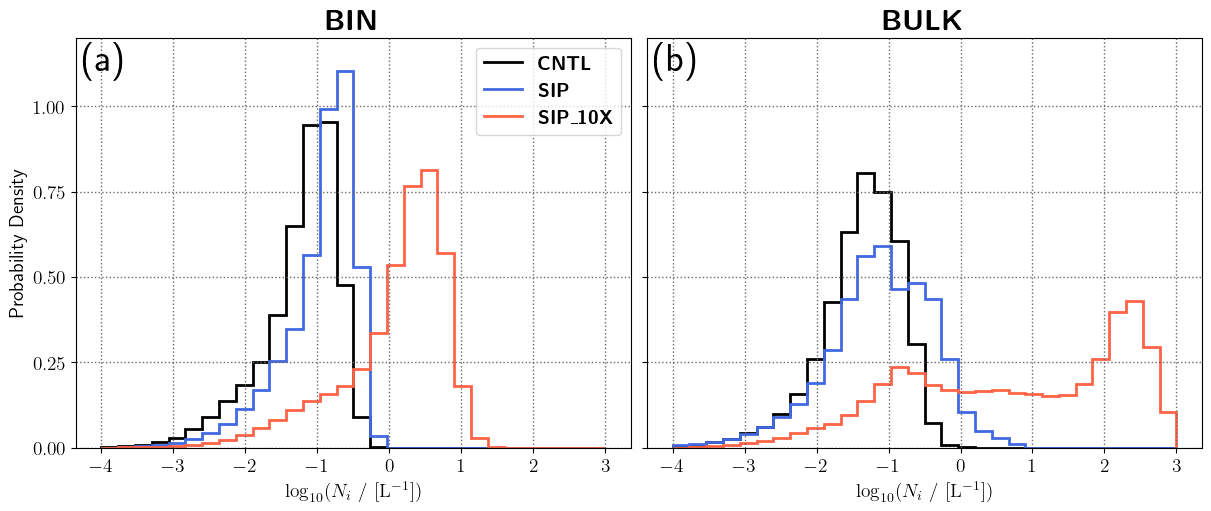

In [10]:
# Normalise to probability density
def to_density(counts, edges):
    total = counts.sum()
    if total == 0:
        return counts.astype(float)
    widths = np.diff(edges)
    return counts / (total * widths)

fig_pdf3d, (ax_bin, ax_bulk) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for counts, color, lw, name in zip(counts_up, sim_colors, sim_lws, sim_labels):
    dens = to_density(counts, log10_edges)
    ax_bin.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)

for counts, color, lw, name in zip(bulk_counts_up, bulk_sim_colors, bulk_sim_lws, bulk_sim_labels):
    dens = to_density(counts, log10_edges)
    ax_bulk.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)

for ax, title in [(ax_bin, r'\textbf{BIN}'),
                  (ax_bulk,  r'\textbf{BULK}')]:
    ax.set_xlabel(r'$\log_{10}(N_i\ /\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)
    #ax.set_ylabel('Probability Density', fontsize=Fontsize)
    ax.tick_params(labelsize=Fontsize)
    #ax.legend(fontsize=Fontsize)
    ax.grid(ls='dotted', lw=1, c='dimgrey')
    ax.set_title(title, fontsize=Fontsize * 1.5)
    #ax.set_yscale('log')
    
ax_bin.legend(fontsize=Fontsize)

ax_bin.set_ylabel('Probability Density', fontsize=Fontsize)
ax_bin.set_ylim(0,1.2)
ax_bulk.set_ylim(0,1.2)
ax_bin.set_yticks(np.arange(0,1.25,0.25))
ax_bulk.set_yticks(np.arange(0,1.25,0.25))
ax_bulk.set_yticklabels([])

ax_bin.text(0.01,0.99,'(a)',fontsize=Fontsize*2.,transform=ax_bin.transAxes,va='top',ha='left')
ax_bulk.text(0.01,0.99,'(b)',fontsize=Fontsize*2.,transform=ax_bulk.transAxes,va='top',ha='left')

plt.show()



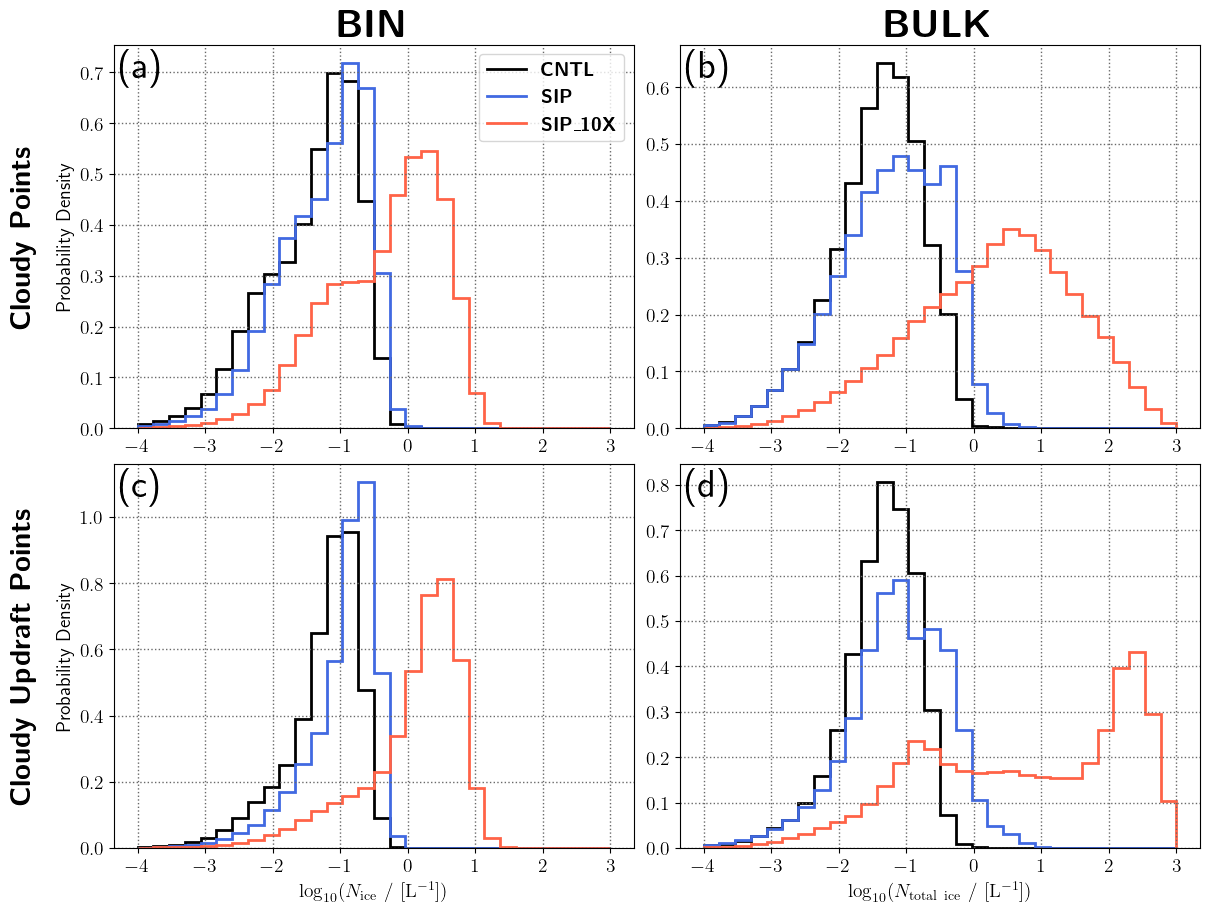

In [12]:
## Normalise to probability density
def to_density(counts, edges):
    total = counts.sum()
    if total == 0:
        return counts.astype(float)
    widths = np.diff(edges)
    return counts / (total * widths)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

# 2. Assign the individual axes objects using standard NumPy 2D indexing
ax_bin_cld = axes[0, 0]   # Top-left
ax_bulk_cld = axes[0, 1]  # Top-right
ax_bin_up = axes[1, 0]    # Bottom-left
ax_bulk_up = axes[1, 1]   # Bottom-right

for counts, color, lw, name in zip(counts_cld, sim_colors, sim_lws, sim_labels):
    dens = to_density(counts, log10_edges)
    ax_bin_cld.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)

for counts, color, lw, name in zip(bulk_counts_cld, bulk_sim_colors, bulk_sim_lws, bulk_sim_labels):
    dens = to_density(counts, log10_edges)
    ax_bulk_cld.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)

for counts, color, lw, name in zip(counts_up, sim_colors, sim_lws, sim_labels):
    dens = to_density(counts, log10_edges)
    ax_bin_up.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)

for counts, color, lw, name in zip(bulk_counts_up, bulk_sim_colors, bulk_sim_lws, bulk_sim_labels):
    dens = to_density(counts, log10_edges)
    ax_bulk_up.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)

for ax in axes.flatten():
    ax.tick_params(labelsize=Fontsize)
    ax.grid(ls='dotted', lw=1, c='dimgrey')
    #ax.set_title(title, fontsize=Fontsize * 1.5)
    #ax.set_yscale('log')

ax_bin_cld.legend(fontsize=Fontsize)

ax_bin_cld.set_ylabel('Probability Density', fontsize=Fontsize)
ax_bin_up.set_ylabel('Probability Density', fontsize=Fontsize)
#ax_bin.set_ylim(0,0.8)
#ax_bulk.set_ylim(0,0.8)
#ax_bin.set_yticks(np.arange(0,0.9,0.1))
#ax_bulk.set_yticks(np.arange(0,0.9,0.1))
#ax_bulk.set_yticklabels([])

ax_bin_cld.text(0.01,0.99,'(a)',fontsize=Fontsize*2.,transform=ax_bin_cld.transAxes,va='top',ha='left')
ax_bulk_cld.text(0.01,0.99,'(b)',fontsize=Fontsize*2.,transform=ax_bulk_cld.transAxes,va='top',ha='left')
ax_bin_up.text(0.01,0.99,'(c)',fontsize=Fontsize*2.,transform=ax_bin_up.transAxes,va='top',ha='left')
ax_bulk_up.text(0.01,0.99,'(d)',fontsize=Fontsize*2.,transform=ax_bulk_up.transAxes,va='top',ha='left')

ax_bin_up.set_xlabel(r'$\log_{10}(N_{\mathrm{ice}}\ /\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)
ax_bulk_up.set_xlabel(r'$\log_{10}(N_{\mathrm{total \ ice}}\ /\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)

ax_bin_cld.set_title(r'\textbf{BIN}',fontsize=Fontsize*2.)
ax_bulk_cld.set_title(r'\textbf{BULK}',fontsize=Fontsize*2.)

#ax_bin_cld.text(-0.25,0.5,r'\textbf{Cloudy} ($q_{\mathrm{t}}$ $>$ 10$^{-3}$ g kg$^{-1}$)',fontsize=Fontsize*1.25,ha='center',va='center',rotation=90,transform=ax_bin_cld.transAxes)
ax_bin_cld.text(-0.175,0.5,r'\textbf{Cloudy Points}',fontsize=Fontsize*1.5,ha='center',va='center',rotation=90,transform=ax_bin_cld.transAxes)
ax_bin_up.text(-0.175,0.5,r'\textbf{Cloudy Updraft Points}',fontsize=Fontsize*1.5,ha='center',va='center',rotation=90,transform=ax_bin_up.transAxes)

plt.show()


In [26]:
path = '/pscratch/sd/m/mckenna/dharma_post/'
bulk_file = 'cntl_bulk_ice_ABIFM_test_sounding_time_series.pkl'
bin_file = 'cntl_bin_ice_sounding_time_series.pkl'

In [27]:
with open(path+bulk_file, 'rb') as file:
    bulk_dict = pickle.load(file)
with open(path+bin_file, 'rb') as file:
    bin_dict = pickle.load(file)

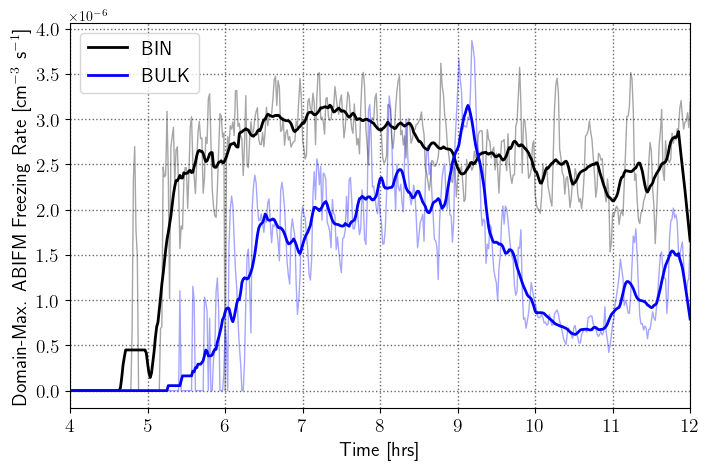

In [36]:
def running_mean(arr, window):
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='same')

running_mean_window = 20

fig = plt.figure(figsize=(8,5))
ax1 = fig.add_subplot(111)
axlist = [ax1]
Fontsize=14
for ax in axlist:
    ax.grid(which='both',ls='dotted',lw=1,c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('Time [hrs]',fontsize=Fontsize)
    ax.set_xlim(4,12)

ax1.set_ylabel('Domain-Max. ABIFM Freezing Rate [cm$^{-3}$ s$^{-1}$]',fontsize=Fontsize)
ax1.plot(bin_dict['time']/3600.,bin_dict['max_in_imm'],alpha=0.35,lw=1,c='k')
ax1.plot(bin_dict['time']/3600.,running_mean(bin_dict['max_in_imm'],running_mean_window),lw=2,c='k',label='BIN')
ax1.plot(bulk_dict['time']/3600.,bulk_dict['max_sh_in_c'],alpha=0.35,lw=1,c='blue')
ax1.plot(bulk_dict['time']/3600.,running_mean(bulk_dict['max_sh_in_c'],running_mean_window),lw=2,c='blue',label='BULK')
ax1.legend(fontsize=Fontsize,loc='upper left')
plt.show()
plt.close()

In [25]:
bin_dict.keys()

dict_keys(['time', 'ntot_1', 'ntot_2', 'nqr', 'nqc', 'nql', 'nd_cld', 'nc_cld', 'nr_cld', 'reff_drops', 'reff_2', 'ql', 'qc', 'qr', 'clwc', 'rwc', 'lwc', 'T', 'wmax', 'rhmax', 'net_cond', 'tke_smag', 'avg_T_flx', 'avg_qv_flx', 'avg_T_sfc', 'avg_ustar', 'avg_precip', 'max_precip', 'rwp', 'clwp', 'lwp', 'max_w', 'cfl', 'iwp', 'iwpf', 'max_qi', 'max_qif', 'max_sh_coag', 'max_sh_in', 'ntot_3', 'reff_3', 'ntot_ifn', 'nbigice_cld', 'nif_cld', 'nqif', 'qif', 'qif2', 'iwc', 'iwc2', 'rhimax', 'net_dep', 'zt', 'zw', 'rhobar'])